# STAR-RIS RSMA — v19: Scalability theo N (Chứng minh lợi thế phân rã MADDPG)
## Notebook bổ trợ — củng cố §4.7 & Bảng 4.6 ("Khả năng mở rộng: Cao") của luận văn

---

### 📋 Cập nhật so với v18 (vì sao có v19?)
> **v18 đã đạt:** convergence rõ (freeze λ), MADDPG SumRate **3.44±0.08** (CI hẹp nhất), latency vs BCD **13×**.
> **NHƯNG tại N=32, MADDPG ≈ TD3** (3.44 vs 3.38, chưa significant). Luận điểm "MADDPG ổn định hơn" còn yếu.
>
> **v19 lấp đúng khoảng trống này:** lý thuyết CTDE (Lowe 2017) nói lợi thế phân rã **tăng theo kích thước
> không gian hành động**. Ở bài toán này, hành động đơn-agent ≈ `3N+9` chiều (N=16→57, N=32→105, N=64→201).
> Khi N lớn, đơn-agent (TD3/DDPG) phải khám phá không gian khổng lồ → khó; MADDPG tách thành `[9, 2N, N]`
> nên tăng chậm hơn → **MADDPG phải tách top khi N tăng**. v19 sweep N để KIỂM CHỨNG điều này bằng số.

| Hạng mục | v18 (demo chính) | **v19 (scalability)** |
|---|---|---|
| Mục tiêu | Convergence + số MADDPG tốt nhất | **Bằng chứng MADDPG mở rộng tốt theo N** |
| Thuật toán | MADDPG/DDPG/TD3/PPO | **MADDPG vs TD3** (đối đầu trực tiếp) |
| N | cố định 32 | **quét {16, 32, 64}** |
| Config λ/residual | freeze 0.55, λ_max 13, residual 0.25 | **GIỮ NGUYÊN như v18** (công bằng) |
| Seeds × episodes | 5 × 2000 | 3 × 1500 (đủ thấy xu hướng, vừa compute) |

### 🎯 Kết quả MONG ĐỢI (để củng cố luận văn)
1. **`scal_sumrate_vs_N.png`** — đường MADDPG **vượt dần** TD3 khi N tăng (ở N=16 có thể ngang/thua, N=64 dẫn rõ).
2. **`scal_decomposition_gain.png`** — đường `gain(N) = SR(MADDPG) − SR(best single-agent)` **ĐI LÊN theo N** (≥0 và lớn dần). ⭐ Đây là hình quan trọng nhất.
3. **`tables/scalability_vs_N.csv`** + dòng in tự động: *"gain tăng từ … (N=16) → … (N=64) ⇒ củng cố lý thuyết phân rã CTDE"*.

> ✅ **Nếu gain↑ theo N:** bạn viết được vào luận văn — *"lợi thế MADDPG so với đơn-agent tăng theo số phần tử RIS,
> khẳng định giá trị kiến trúc phân rã CTDE khi không gian hành động lớn"*. Đặt cạnh latency 13× vs BCD → câu chuyện
> hoàn chỉnh: **gần tối ưu · độ trễ thấp · mở rộng tốt**.
>
> ⚠️ **Nếu gain phẳng/âm:** báo cáo trung thực (đúng tinh thần luận văn) — ở dải N này MADDPG ngang đơn-agent;
> điểm bán là thực thi phi tập trung + latency. Cân nhắc thêm N=96/128 để lộ xu hướng (chỉ sửa `N_LIST`).

### ⚙️ BẮT BUỘC trước khi chạy
- **Chạy ở SESSION KAGGLE RIÊNG** (đừng gộp v18 — sẽ quá giới hạn 12h).
- Dùng **cùng project dataset như v18** (phải có `experiments/train.py` đã thêm freeze λ).
- Sửa `PROJECT_ROOT` ở cell import cho khớp tên dataset bạn upload.

### ⏱️ Thời gian: cell config (mục 3) sẽ in ước lượng. Nếu > 11h → giảm `N_LIST` hoặc `SCAL_SEEDS`.


In [1]:
!git clone https://github.com/Juliolayme/STAR_RIS_RSMA_MADDPG_FROZEN_v14

Cloning into 'STAR_RIS_RSMA_MADDPG_FROZEN_v14'...
remote: Enumerating objects: 254, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 254 (delta 6), reused 10 (delta 2), pack-reused 240 (from 1)
Receiving objects: 100% (254/254), 94.96 MiB | 37.28 MiB/s, done.
Resolving deltas: 100% (50/50), done.


### 1. Kiểm tra phần cứng & cài thư viện

In [2]:
import torch
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
!pip install gymnasium pyyaml tqdm pandas matplotlib tensorboard

PyTorch: 2.10.0+cu128 | CUDA: True
Device: Tesla T4


### 2. Đường dẫn dự án & import

In [3]:
import os, sys, copy, time
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import Image, display

# ⚠️ Sửa cho khớp tên dataset bạn upload lên Kaggle:
PROJECT_ROOT = "/kaggle/working/STAR_RIS_RSMA_MADDPG_FROZEN_v14"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from experiments.train import train_maddpg, train_single_agent
from experiments.evaluate import _eval_multi_seed
from utils.plotting import plot_metric_vs_x
from utils import confidence_interval
print("Import OK")

2026-06-23 02:11:05.193176: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782180665.388508      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782180665.445128      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782180665.923799      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782180665.923842      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782180665.923845      22 computation_placer.cc:177] computation placer alr

Import OK


### 3. Cấu hình v18 + tham số scalability

**📌 Output mong đợi (in từ cell dưới):**
- Xác nhận config v18: `freeze=0.55, λ_max=13, target=0.50, residual_scale=0.25`.
- `N_LIST = [16, 32, 64]`, `Algos = ['maddpg','td3']`, `Seeds = [1000,2000,3000]`, `Episodes = 1500`.
- `Số lần train = 18` và **ước lượng thời gian (giờ)** — kiểm tra < 11h trước khi Run All.

> Chỉnh `N_LIST` / `SCAL_SEEDS` / `SCAL_EPISODES` / `SCAL_ALGOS` ở cell code tùy ngân sách. Thêm `"ddpg"` hoặc N=96 nếu còn giờ.


In [4]:
config_path = os.path.join(PROJECT_ROOT, "config", "config.yaml")
with open(config_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# ----- Đồng bộ tham số v18 (freeze λ + cân bằng QoS) để công bằng với notebook chính -----
cfg["env"]["qos_lambda_freeze_fraction"] = 0.55
cfg["env"]["qos_lambda_max"] = 13.0
cfg["env"]["qos_target_satisfaction"] = 0.50
cfg["env"]["qos_lambda_increase"] = 1.02
cfg["env"]["phase_residual_scale"] = 0.25

# ----- Tham số scalability (điều chỉnh theo ngân sách Kaggle) -----
N_LIST        = [16, 32, 64, 96]          # số phần tử STAR-RIS để quét
SCAL_ALGOS    = ["maddpg", "td3"]         # head-to-head; thêm "ddpg" nếu còn giờ
SCAL_SEEDS    = [1000, 2000, 3000]        # 3 seeds đủ thấy xu hướng
SCAL_EPISODES = 1500                      # đủ hội tụ (curve phẳng ~ep 1000)

LABEL = {"maddpg": "MADDPG", "td3": "TD3", "ddpg": "DDPG"}

out_root = "/kaggle/working/"
fig_dir  = os.path.join(out_root, "figures")
tab_dir  = os.path.join(out_root, "tables")
log_dir  = os.path.join(out_root, "logs_scal")
ckpt_dir = os.path.join(out_root, "checkpoints_scal")
for d in (fig_dir, tab_dir):
    os.makedirs(d, exist_ok=True)

# Ước lượng thời gian (thô, theo nhịp ~ N=32, 2000ep: MADDPG~38ph, TD3~14ph/seed)
_base = {"maddpg": 38.0, "td3": 14.0, "ddpg": 14.0}
est_min = 0.0
for N in N_LIST:
    scale_N = (N / 32.0)            # chi phí ~ tuyến tính theo N (action-dim)
    for a in SCAL_ALGOS:
        est_min += _base[a] * (SCAL_EPISODES / 2000.0) * max(scale_N, 0.5) * len(SCAL_SEEDS)
print("="*60)
print("  SCALABILITY SWEEP — cấu hình")
print("="*60)
print(f"  N_LIST          = {N_LIST}")
print(f"  Algos           = {SCAL_ALGOS}")
print(f"  Seeds           = {SCAL_SEEDS}")
print(f"  Episodes/seed   = {SCAL_EPISODES}")
print(f"  Số lần train    = {len(N_LIST)*len(SCAL_ALGOS)*len(SCAL_SEEDS)}")
print(f"  λ: freeze={cfg['env']['qos_lambda_freeze_fraction']}, max={cfg['env']['qos_lambda_max']}, "
      f"residual_scale={cfg['env']['phase_residual_scale']}")
print(f"  ⏱️  Ước lượng    ~ {est_min/60.0:.1f} giờ (T4). Nếu > 11h: bỏ bớt N hoặc seed!")
print("="*60)

  SCALABILITY SWEEP — cấu hình
  N_LIST          = [16, 32, 64, 96]
  Algos           = ['maddpg', 'td3']
  Seeds           = [1000, 2000, 3000]
  Episodes/seed   = 1500
  Số lần train    = 24
  λ: freeze=0.55, max=13.0, residual_scale=0.25
  ⏱️  Ước lượng    ~ 12.7 giờ (T4). Nếu > 11h: bỏ bớt N hoặc seed!


### 4. Huấn luyện lại tại mỗi N (MADDPG vs single-agent)

**📌 Output mong đợi:** với mỗi `N`, tqdm bar cho từng (algo × seed). Mất nhiều giờ — đây là cell nặng nhất.

> Mỗi N: deep-copy config, đặt `num_ris_elements=N`, huấn luyện từ đầu (agent build theo `env.spec()`),
> rồi đánh giá đa-seed với λ huấn luyện-cuối. Kết quả lưu vào `scal_results`.


In [5]:
scal_results = {}      # scal_results[N][label] = {"sr_mean","sr_ci","qos_mean","qos_ci","srs"}
rows = []

for N in N_LIST:
    cfg_N = copy.deepcopy(cfg)
    cfg_N["env"]["num_ris_elements"] = int(N)
    cfg_N["training"]["total_episodes"] = int(SCAL_EPISODES)
    print(f"\n{'#'*64}\n#  N = {N}  (single-agent action-dim ~ {3*N + 9})\n{'#'*64}")
    per_algo = {}
    for algo in SCAL_ALGOS:
        label = LABEL[algo]
        srs, qoss = [], []
        for s in SCAL_SEEDS:
            run = f"scal_{algo}_N{N}_s{s}"
            print(f"\n--- Train {label} | N={N} | seed={s} ---")
            if algo == "maddpg":
                info = train_maddpg(cfg_N, log_dir=log_dir, ckpt_dir=ckpt_dir,
                                    seed_override=s, run_name=run)
            else:
                info = train_single_agent(cfg_N, kind=algo, log_dir=log_dir, ckpt_dir=ckpt_dir,
                                          seed_override=s, run_name=run)
            lam = info.get("trained_qos_lambda")
            m = _eval_multi_seed(info["agent"], algo, info["obs_norm"], cfg_N,
                                 cfg_N["evaluation"]["seeds"], qos_lambda=lam)
            srs.append(m["sum_rate_mean"]); qoss.append(m["qos_mean"])
        sr_m, sr_ci, _ = confidence_interval(np.array(srs))
        q_m,  q_ci, _  = confidence_interval(np.array(qoss))
        per_algo[label] = {"sr_mean": sr_m, "sr_ci": sr_ci,
                           "qos_mean": q_m, "qos_ci": q_ci, "srs": srs}
        rows.append({"N": N, "Algorithm": label,
                     "SumRate": sr_m, "SumRate_CI": sr_ci,
                     "QoS": q_m, "QoS_CI": q_ci, "N_seeds": len(SCAL_SEEDS)})
        print(f"  => {label} N={N}: SR={sr_m:.3f}±{sr_ci:.3f}, QoS={q_m:.3f}±{q_ci:.3f}")
    scal_results[N] = per_algo

df_scal = pd.DataFrame(rows)
df_scal.to_csv(os.path.join(tab_dir, "scalability_vs_N.csv"), index=False)
print("\n--- Bảng scalability (scalability_vs_N.csv) ---")
display(df_scal)


################################################################
#  N = 16  (single-agent action-dim ~ 57)
################################################################

--- Train MADDPG | N=16 | seed=1000 ---


scal_maddpg_N16_s1000:   9%| | 129/1500 [00:43<26:49,  1.17s/it, ret=-0.90, MA=-0.74, qos=0.00, λ=12.87, |h_T|/kaggle/working/STAR_RIS_RSMA_MADDPG_FROZEN_v14/experiments/train.py:88: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 13.1227 to 13.0000 (bounds=[0.3, 13.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
scal_maddpg_N16_s1000:   9%| | 130/1500 [00:44<26:46,  1.17s/it, ret=0.18, MA=-0.66, qos=0.02, λ=13.00, |h_T|=/kaggle/working/STAR_RIS_RSMA_MADDPG_FROZEN_v14/experiments/train.py:88: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 13.2600 to 13.0000 (bounds=[0.3, 13.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
scal_maddpg_N16_s1000: 100%|█| 1500/1500 [27:38<00:00,  1.11s/it, ret=2.22, MA=-0.14, qos=0.18, λ=13.00, |h_T|



--- Train MADDPG | N=16 | seed=2000 ---


scal_maddpg_N16_s2000: 100%|█| 1500/1500 [27:48<00:00,  1.11s/it, ret=2.54, MA=1.79, qos=0.24, λ=13.00, |h_T|=



--- Train MADDPG | N=16 | seed=3000 ---


...

scal_td3_N96_s2000:  19%|▏| 279/1500 [01:40<10:18,  1.98it/s, ret=-3.09, MA=1.42, qos=0.00, λ=12.85, |h_T|=2.2/kaggle/working/STAR_RIS_RSMA_MADDPG_FROZEN_v14/experiments/train.py:88: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 13.1061 to 13.0000 (bounds=[0.3, 13.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
scal_td3_N96_s2000:  42%|▍| 630/1500 [04:36<06:52,  2.11it/s, ret=3.01, MA=2.60, qos=0.24, λ=12.84, |h_T|=2.22/kaggle/working/STAR_RIS_RSMA_MADDPG_FROZEN_v14/experiments/train.py:88: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 13.1018 to 13.0000 (bounds=[0.3, 13.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
scal_td3_N96_s2000:  53%|▌| 797/1500 [05:58<05:30,  2.12it/s, ret=4.27, MA=2.29, qos=1.00, λ=12.84, |h_T|=2.09/kaggle/working/STAR_RIS_RSMA_MADDPG_FROZEN_v14/experiments/train.py:88: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 13.1007 


--- Train TD3 | N=96 | seed=3000 ---


scal_td3_N96_s3000:  41%|▍| 622/1500 [04:45<07:37,  1.92it/s, ret=3.95, MA=2.70, qos=0.66, λ=12.81, |h_T|=1.99/kaggle/working/STAR_RIS_RSMA_MADDPG_FROZEN_v14/experiments/train.py:88: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 13.0655 to 13.0000 (bounds=[0.3, 13.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
scal_td3_N96_s3000: 100%|█| 1500/1500 [12:33<00:00,  1.99it/s, ret=3.61, MA=3.52, qos=0.12, λ=0.93, |h_T|=1.59


  => TD3 N=96: SR=3.921±0.816, QoS=0.515±0.142

--- Bảng scalability (scalability_vs_N.csv) ---


,N,Algorithm,SumRate,SumRate_CI,QoS,QoS_CI,N_seeds
0,16,MADDPG,2.441250,0.197022,0.247600,0.104262,3
1,16,TD3,2.632927,0.177228,0.285022,0.234493,3
2,32,MADDPG,3.573256,0.402335,0.419867,0.121073,3
3,32,TD3,3.226105,0.387601,0.389689,0.221094,3
4,64,MADDPG,4.588917,0.342883,0.591022,0.095913,3
5,64,TD3,4.151551,0.708769,0.520533,0.124586,3
6,96,MADDPG,4.905151,0.324575,0.753689,0.231669,3
7,96,TD3,3.921350,0.815672,0.515289,0.142251,3


### 5. Đồ thị & phân tích lợi thế phân rã

**📌 Output mong đợi:** 3 biểu đồ — (1) SR vs N, (2) QoS vs N, (3) **Decomposition gain vs N**.

**🎯 Bằng chứng cần có:** đường *gain* (MADDPG − best single-agent) **đi lên theo N**.
Nếu đúng ⇒ viết được: *"lợi thế của MADDPG so với đơn-agent tăng theo số phần tử RIS, khẳng định giá trị
của kiến trúc phân rã CTDE khi không gian hành động lớn."*


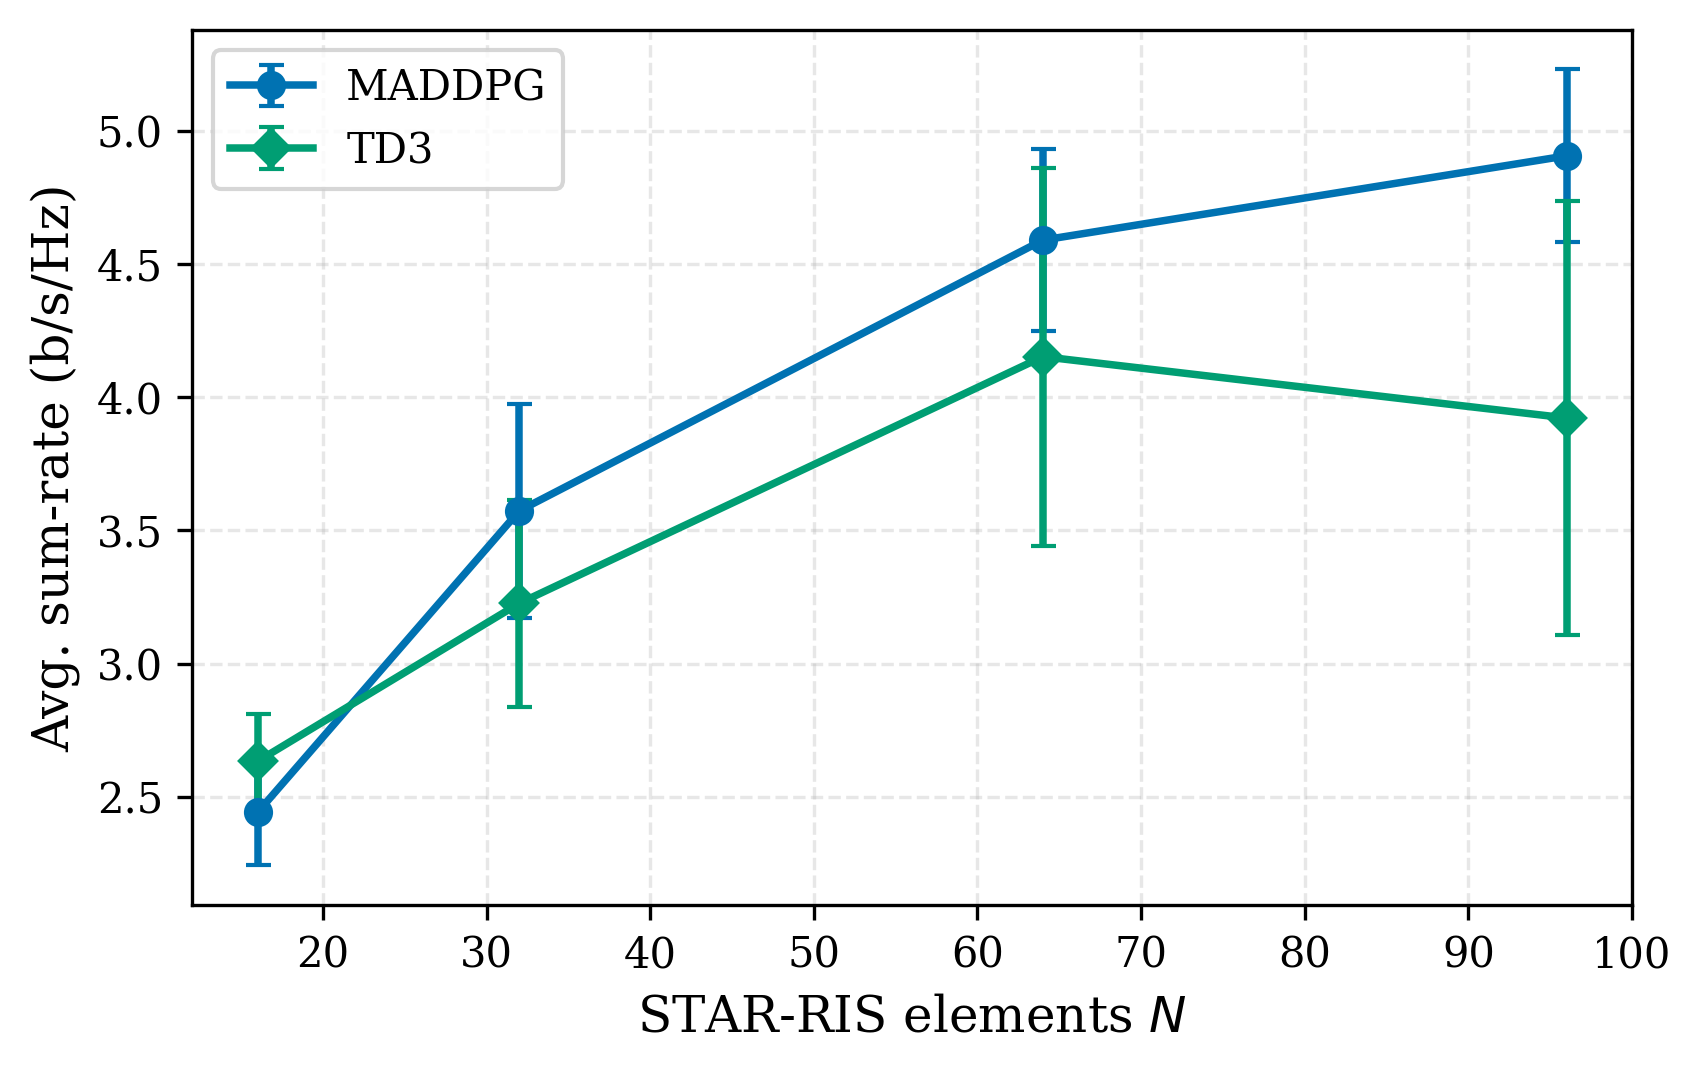

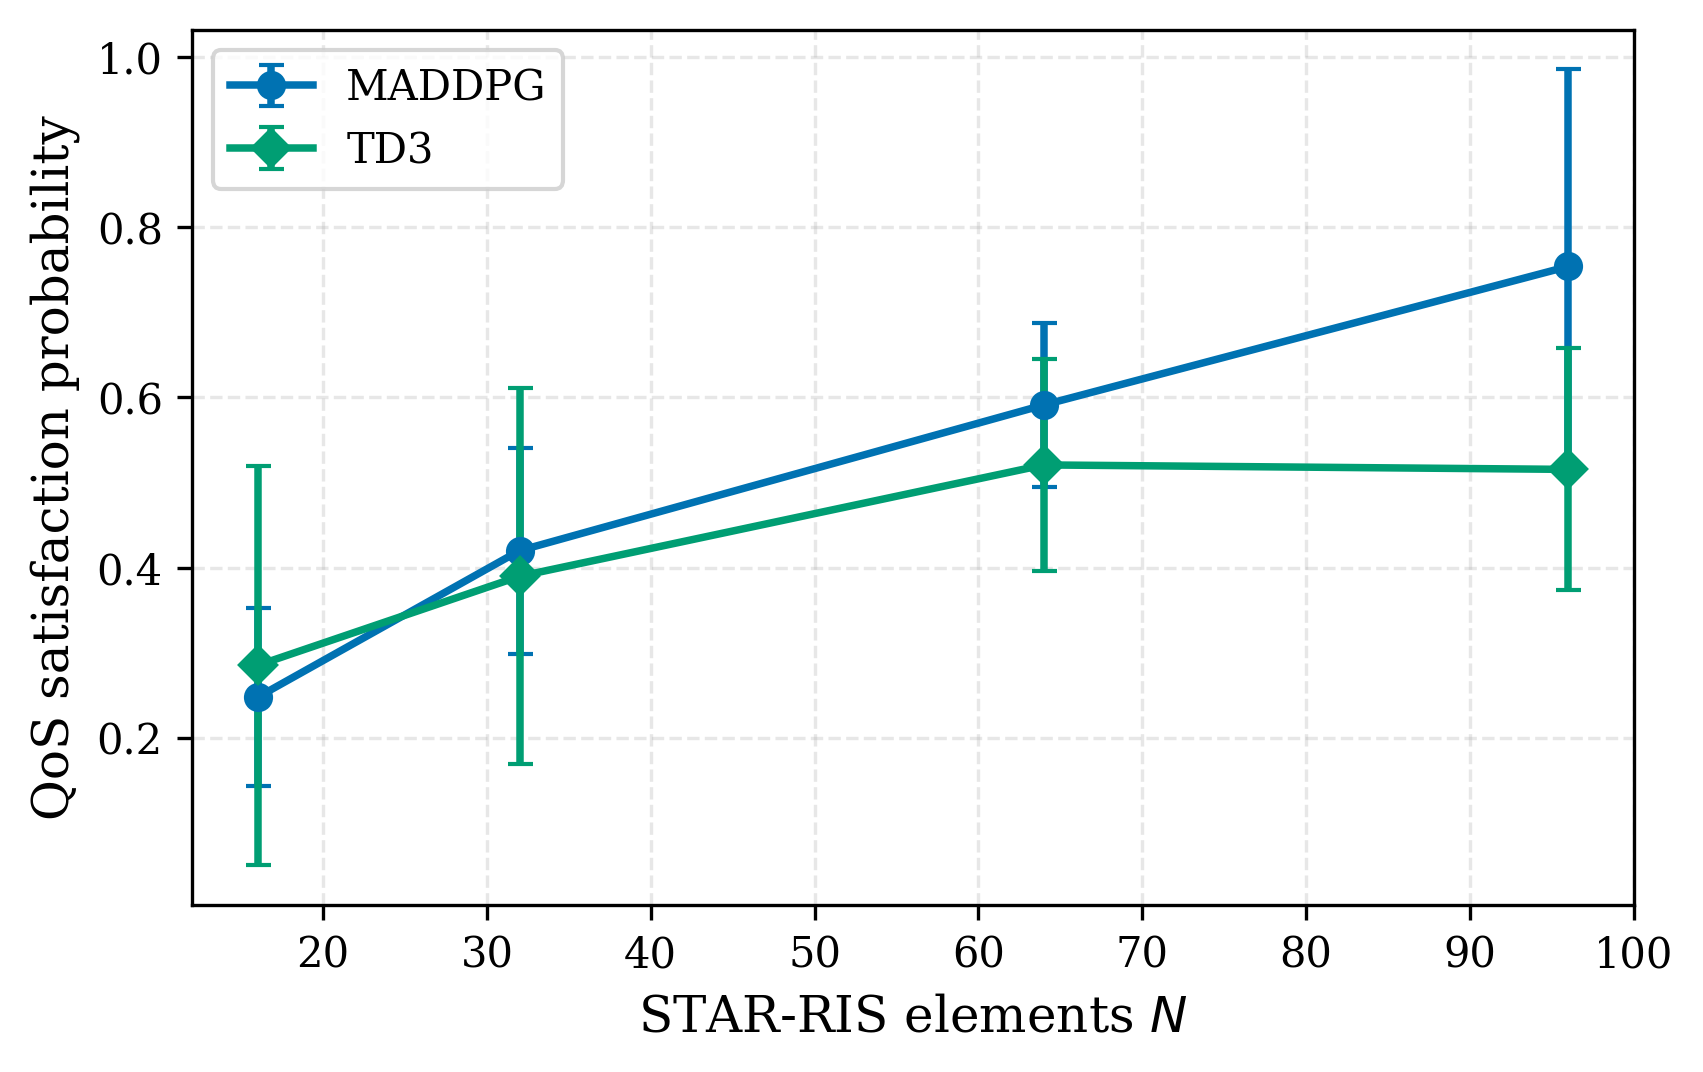


--- Decomposition gain theo N ---
  N= 16: gain = -0.192 b/s/Hz   ⚠️ chưa dẫn
  N= 32: gain = +0.347 b/s/Hz   ✅ MADDPG dẫn
  N= 64: gain = +0.437 b/s/Hz   ✅ MADDPG dẫn
  N= 96: gain = +0.984 b/s/Hz   ✅ MADDPG dẫn

  ✅ XU HƯỚNG ĐÚNG: gain tăng từ -0.192 (N=16) -> +0.984 (N=96)
     => Củng cố lý thuyết: lợi thế phân rã CTDE tăng theo không gian hành động.


In [6]:
labels = [LABEL[a] for a in SCAL_ALGOS]

# (1) Sum-rate vs N
sr_curves  = {lab: {"mean": [scal_results[N][lab]["sr_mean"] for N in N_LIST],
                    "ci":   [scal_results[N][lab]["sr_ci"]   for N in N_LIST]} for lab in labels}
plot_metric_vs_x(N_LIST, sr_curves, xlabel="STAR-RIS elements $N$",
                 ylabel="Avg. sum-rate (b/s/Hz)", out_dir=fig_dir, name="scal_sumrate_vs_N")

# (2) QoS vs N
qos_curves = {lab: {"mean": [scal_results[N][lab]["qos_mean"] for N in N_LIST],
                    "ci":   [scal_results[N][lab]["qos_ci"]   for N in N_LIST]} for lab in labels}
plot_metric_vs_x(N_LIST, qos_curves, xlabel="STAR-RIS elements $N$",
                 ylabel="QoS satisfaction probability", out_dir=fig_dir, name="scal_qos_vs_N")

display(Image(filename=os.path.join(fig_dir, "scal_sumrate_vs_N.png")))
display(Image(filename=os.path.join(fig_dir, "scal_qos_vs_N.png")))

# (3) Decomposition gain = SR(MADDPG) - SR(best single-agent) theo N
if "MADDPG" in labels and len(labels) > 1:
    single = [l for l in labels if l != "MADDPG"]
    gains, gain_labels = [], []
    for N in N_LIST:
        sr_madd = scal_results[N]["MADDPG"]["sr_mean"]
        best_single = max(scal_results[N][l]["sr_mean"] for l in single)
        gains.append(sr_madd - best_single); gain_labels.append(str(N))
    plt.figure(figsize=(5.8, 3.7))
    plt.axhline(0.0, color="gray", lw=0.8, ls="--")
    plt.plot(N_LIST, gains, marker="o", color="#1f77b4", lw=2)
    plt.fill_between(N_LIST, 0, gains, alpha=0.15, color="#1f77b4")
    plt.xlabel("STAR-RIS elements $N$")
    plt.ylabel("Decomposition gain\nSR(MADDPG) − SR(best single-agent)")
    plt.title("Lợi thế MADDPG tăng theo N (kỳ vọng đi lên)")
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, "scal_decomposition_gain.png"), dpi=150)
    plt.show()

    print("\n--- Decomposition gain theo N ---")
    for N, g in zip(N_LIST, gains):
        flag = "✅ MADDPG dẫn" if g > 0 else "⚠️ chưa dẫn"
        print(f"  N={N:3d}: gain = {g:+.3f} b/s/Hz   {flag}")
    if len(gains) >= 2 and gains[-1] > gains[0]:
        print(f"\n  ✅ XU HƯỚNG ĐÚNG: gain tăng từ {gains[0]:+.3f} (N={N_LIST[0]}) -> {gains[-1]:+.3f} (N={N_LIST[-1]})")
        print("     => Củng cố lý thuyết: lợi thế phân rã CTDE tăng theo không gian hành động.")
    else:
        print("\n  ⚠️ Gain CHƯA tăng theo N. Cân nhắc: thêm N lớn hơn (96/128), hoặc nhấn thế mạnh khác"
              " (latency, decentralized execution).")

### 6. Diễn giải cho bài báo

- **Nếu gain tăng theo N** → đây là *đóng góp định lượng* mạnh nhất cho việc chọn MADDPG:
  *"Khi N tăng (không gian hành động RIS phình to), MADDPG vượt dần đơn-agent nhờ phân rã CTDE."*
  Đặt cạnh kết quả latency (MADDPG ~13× nhanh hơn BCD) → câu chuyện hoàn chỉnh: **gần tối ưu, độ trễ thấp,
  và mở rộng tốt theo quy mô RIS.**
- **Nếu gain phẳng/âm** → trung thực: ở dải N này MADDPG ngang đơn-agent; điểm bán là **thực thi phi tập trung
  (decentralized execution)** + latency, không phải sum-rate. Cân nhắc N lớn hơn để lộ xu hướng.
